# Consumer Engagement & Trend Analysis — Mero Mahinawari

**App:** Mero Mahinawari ( Nepali period-tracking mobile application )
**Dataset:** 8,000 activity logs across 1,560 unique users
**Goal:** Clean raw engagement data and uncover usage patterns across features, time, and session behaviour.

# IMPORT AND LOAD CSV


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# ── Plot aesthetics ──────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi"      : 120,
    "axes.titlesize"  : 13,
    "axes.titleweight": "bold",
    "axes.labelsize"  : 11,
    "xtick.labelsize" : 10,
    "ytick.labelsize" : 10,
})

# ── Load dataset ─────────────────────────────────────────────
df_raw = pd.read_csv("../data'/mero_mahinawari_engagement_log.csv",
                     parse_dates=["registration_date", "activity_date"])

print(f"Shape  : {df_raw.shape}")
print(f"Columns: {df_raw.columns.tolist()}")
df_raw.head()

Shape  : (12844, 6)
Columns: ['user_id', 'registration_date', 'activity_date', 'feature_used', 'session_duration_minutes', 'device_os']


,user_id,registration_date,activity_date,feature_used,session_duration_minutes,device_os
0,MM_1001,2024-09-07,2024-11-04,Health Articles,11.7,Android
1,MM_1001,2024-09-07,2024-09-11,Period Tracker,13.5,Android
2,MM_1001,2024-09-07,2024-10-21,Period Tracker,7.3,Android
3,MM_1001,2024-09-07,2024-09-27,Period Tracker,11.6,Android
4,MM_1001,2024-09-07,2024-09-18,Community Forum,14.4,iOS


# INITIAL INSPECTION

In [7]:
# ── Basic info & missing value audit ────────────────────────
print("=" * 50)
print("DATASET INFO")
print("=" * 50)
df_raw.info()

print("\n" + "=" * 50)
print("MISSING VALUES")
print("=" * 50)
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
pd.DataFrame({"missing_count": missing, "missing_%": missing_pct})

DATASET INFO
<class 'pandas.DataFrame'>
RangeIndex: 12844 entries, 0 to 12843
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   user_id                   12844 non-null  str           
 1   registration_date         12844 non-null  datetime64[us]
 2   activity_date             12844 non-null  datetime64[us]
 3   feature_used              12844 non-null  str           
 4   session_duration_minutes  12587 non-null  float64       
 5   device_os                 12844 non-null  str           
dtypes: datetime64[us](2), float64(1), str(3)
memory usage: 602.2 KB

MISSING VALUES


,missing_count,missing_%
user_id,0,0.0
registration_date,0,0.0
activity_date,0,0.0
feature_used,0,0.0
session_duration_minutes,257,2.0
device_os,0,0.0



## Data Cleaning



## Drop NaN and Cap Outliers

In [8]:
# ── Step 1: Drop rows where session_duration_minutes is NaN ──
rows_before = len(df_raw)
df = df_raw.dropna(subset=["session_duration_minutes"]).copy()
rows_dropped = rows_before - len(df)
print(f"Rows dropped (NaN duration) : {rows_dropped}")

# ── Step 2: Cap outliers at 60 minutes (Winsorisation) ───────
DURATION_CAP = 60
outliers_before = (df["session_duration_minutes"] > DURATION_CAP).sum()
df["session_duration_minutes"] = df["session_duration_minutes"].clip(upper=DURATION_CAP)
print(f"Sessions capped at {DURATION_CAP} min   : {outliers_before}")
print(f"Cleaned dataset shape        : {df.shape}")

# ── Quick sanity check ────────────────────────────────────────
df["session_duration_minutes"].describe().round(2)

Rows dropped (NaN duration) : 257
Sessions capped at 60 min   : 15
Cleaned dataset shape        : (12587, 6)


count    12587.00
mean         8.14
std          4.40
min          1.00
25%          4.60
50%          8.10
75%         11.60
max         60.00
Name: session_duration_minutes, dtype: float64

## Feature Engineering

In [9]:
# ── Derive time columns for trend analysis ───────────────────
df["activity_month"]    = df["activity_date"].dt.to_period("M")
df["activity_month_ts"] = df["activity_month"].dt.to_timestamp()   # Period → Timestamp
df["activity_yearweek"] = df["activity_date"].dt.to_period("W")

print("Sample of engineered columns:")
df[["user_id","activity_date","activity_month","activity_yearweek"]].head()

Sample of engineered columns:


,user_id,activity_date,activity_month,activity_yearweek
0,MM_1001,2024-11-04,2024-11,2024-11-04/2024-11-10
1,MM_1001,2024-09-11,2024-09,2024-09-09/2024-09-15
2,MM_1001,2024-10-21,2024-10,2024-10-21/2024-10-27
3,MM_1001,2024-09-27,2024-09,2024-09-23/2024-09-29
4,MM_1001,2024-09-18,2024-09,2024-09-16/2024-09-22


## Exploratory Data Analysis (EDA)



## Chart 1 — Feature Usage Frequency

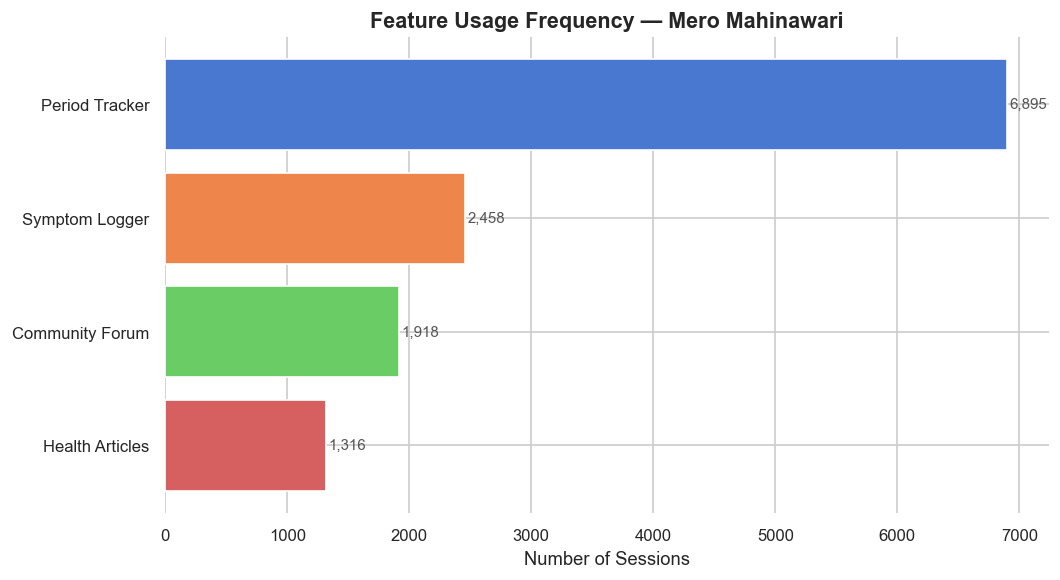

Chart saved.


In [10]:
# ── Chart 1: Feature Usage Frequency ────────────────────────
feature_counts = (
    df["feature_used"]
    .value_counts()
    .reset_index()
    .rename(columns={"index": "feature_used", "count": "session_count"})
)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(
    feature_counts["feature_used"],
    feature_counts["session_count"],
    color=sns.color_palette("muted", len(feature_counts))
)

# Annotate bar ends
for bar in bars:
    ax.text(
        bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
        f"{int(bar.get_width()):,}",
        va="center", ha="left", fontsize=9, color="#555"
    )

ax.set_xlabel("Number of Sessions")
ax.set_title("Feature Usage Frequency — Mero Mahinawari")
ax.invert_yaxis()
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.savefig("../outputs/01_feature_usage.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved.")

## Chart 2 — Monthly Activity Trend

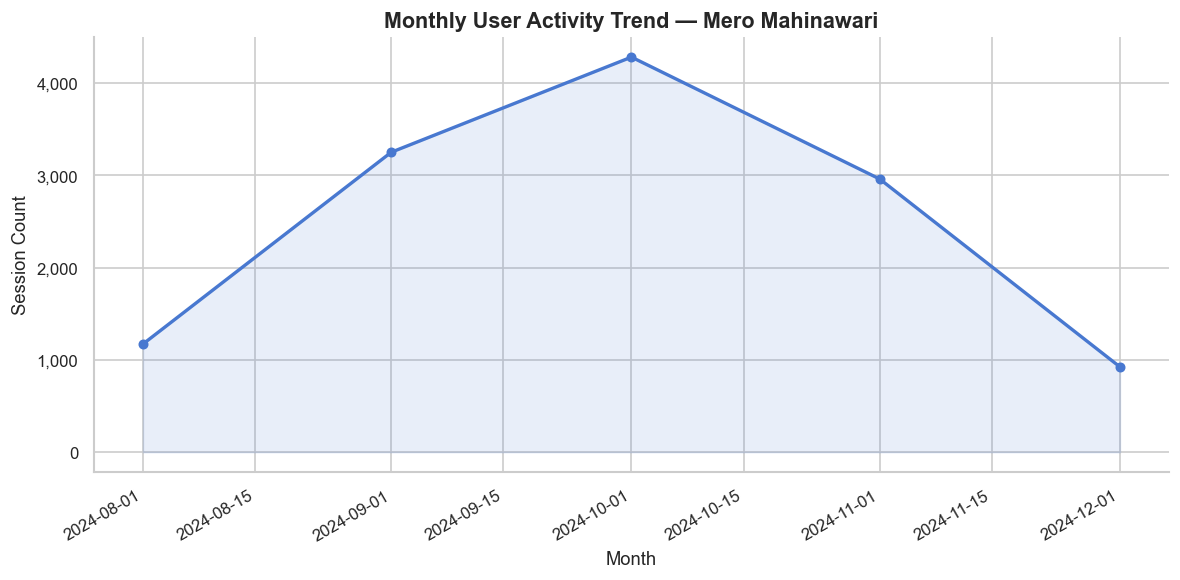

Chart saved.


In [11]:
# ── Chart 2: Monthly Activity Trend (log count over time) ───
monthly_activity = (
    df.groupby("activity_month_ts")
    .size()
    .reset_index(name="session_count")
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    monthly_activity["activity_month_ts"],
    monthly_activity["session_count"],
    marker="o", linewidth=2, markersize=5,
    color=sns.color_palette("muted")[0]
)
ax.fill_between(
    monthly_activity["activity_month_ts"],
    monthly_activity["session_count"],
    alpha=0.12,
    color=sns.color_palette("muted")[0]
)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_xlabel("Month")
ax.set_ylabel("Session Count")
ax.set_title("Monthly User Activity Trend — Mero Mahinawari")
fig.autofmt_xdate()
sns.despine()
plt.tight_layout()
plt.savefig("../outputs/02_monthly_trend.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved.")

## Chart 3 — Session Duration Distribution


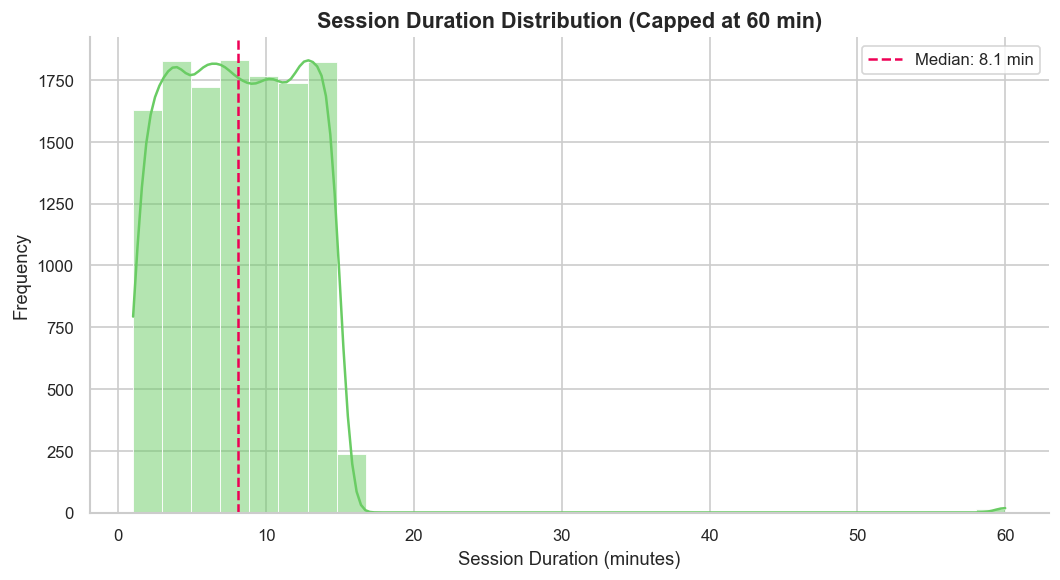

Chart saved.


In [12]:
# ── Chart 3: Session Duration Distribution (post-clean) ─────
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(
    df["session_duration_minutes"],
    bins=30, kde=True,
    color=sns.color_palette("muted")[2],
    edgecolor="white", linewidth=0.5,
    ax=ax
)

median_val = df["session_duration_minutes"].median()
ax.axvline(median_val, color="#e05", linestyle="--", linewidth=1.5,
           label=f"Median: {median_val:.1f} min")
ax.legend(fontsize=10)

ax.set_xlabel("Session Duration (minutes)")
ax.set_ylabel("Frequency")
ax.set_title("Session Duration Distribution (Capped at 60 min)")
sns.despine()
plt.tight_layout()
plt.savefig("../outputs/03_session_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved.")

# Summary Stats 



In [13]:
# ── Summary table ────────────────────────────────────────────
summary = df.groupby("feature_used").agg(
    sessions        = ("user_id", "count"),
    unique_users    = ("user_id", "nunique"),
    avg_duration    = ("session_duration_minutes", "mean"),
    median_duration = ("session_duration_minutes", "median"),
).round(2).sort_values("sessions", ascending=False)

print("Feature-level engagement summary:")
summary

Feature-level engagement summary:


,sessions,unique_users,avg_duration,median_duration
feature_used,,,,
Period Tracker,6895,1372,8.19,8.20
Symptom Logger,2458,1063,8.21,8.10
Community Forum,1918,937,7.97,7.75
Health Articles,1316,786,7.97,7.90
